In [1]:
%load_ext autoreload
%autoreload 2

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
from scipy.stats import spearmanr, pearsonr
from sklearn.cross_decomposition import CCA
from sklearn.preprocessing import StandardScaler
from functools import partial

# Add parent directory to path
notebook_dir = os.path.dirname(os.path.abspath(''))
if notebook_dir not in sys.path:
    sys.path.append(os.path.dirname(notebook_dir))

# Import project modules
from notebooks.config import *
import processing, utils, plotting, heatmap
import pseudoclusters, test_structures
import spatial_cca, imputations

# Configuration
configure_matplotlib()
SAVE_FIGURES = True
fig_path = MERFISH_FIGURE_DIR
save_figure = partial(save_figure, dir_path=fig_path)
output_path = TMP_OUT_DIR
cpm_scl = CPM_SCL_MERFISH
plt.rcParams["image.cmap"] = CMAP_NAME

print(f"scanpy version: {sc.__version__}")

PROJECT_ROOT: /root/capsule
CODE_DIR: /root/capsule/code
CODE_DIR exists: True
Python path includes CODE_DIR: True
scanpy version: 1.11.3


# Data Loading and Preprocessing

In [2]:
def load_and_preprocess_data():
    """Load mesh and MERFISH data, perform initial preprocessing"""
    # Load mesh data
    print("Loading mesh data...")
    allmeshes = utils.load_mesh(MESH_DIR)
    mesh = allmeshes['250513_LC_core_67_mesh_shrunk']
    mesh.vertices /= 25  # Scale vertices to mm

    # Load MERFISH data
    print("Loading MERFISH data...")
    filename = os.path.join(MERFISH_DATA_DIR, 'adata_mer_subset_2_6k.h5ad')
    adata_mer = sc.read_h5ad(filename)
    print(f"Original data shape: {adata_mer.shape}")

    # Filter out cluster 5 and create UMAP
    adata_mer = adata_mer[adata_mer.obs['leiden'] != '5', :]
    print(f"After filtering: {adata_mer.shape}")

    # Create UMAP embedding
    print("Creating UMAP embedding...")
    sc.pp.neighbors(adata_mer, use_rep="X_scVI", random_state=307)
    sc.tl.umap(adata_mer, random_state=210)
    
    return mesh, allmeshes, adata_mer

# Load and preprocess data
mesh, allmeshes, adata_mer = load_and_preprocess_data()

Loading mesh data...
Loading MERFISH data...
Original data shape: (2651, 315)
After filtering: (2252, 315)
Creating UMAP embedding...


# Perform CCA Analysis

In [3]:
scl_multiplier = 25
def perform_cca_analysis(adata_mer, n_components=2, scl_multiplier=scl_multiplier):
    """Perform CCA analysis between gene expression and spatial coordinates"""
    S_mer_fo_cca = processing.get_hemi(adata_mer.obsm['spatial'], MESH_DIR)
    cca, X_c, S_c, canonical_correlations = spatial_cca.perform_cca(
        adata_mer.X, S_mer_fo_cca, 
        n_components=n_components, 
        scl_multiplier=scl_multiplier
    )    
    print(f"Canonical correlations: {canonical_correlations}")
    return cca, X_c, S_c, canonical_correlations

# Perform CCA analysis
cca, X_c, S_c, canonical_correlations = perform_cca_analysis(adata_mer)

Canonical correlations: [0.9292420438702444, 0.8019028227799995]


# Visualize CCA Results in Spatial Coordinates



In [4]:
# Visualize CCA component 1 in sagittal and coronal views
print("Visualizing CCA component 1 in spatial coordinates...")
s = 10
k = 1  # Component to visualize (0-indexed)
scale_factor = 1 * scl_multiplier
vector = (cca.y_weights_[:, k])
vector_scaled = vector * scale_factor
allspatial = adata_mer.obsm['spatial'].copy()
allspatial_j = plotting.add_jitter(allspatial,scl_jitter=0.05)

Visualizing CCA component 1 in spatial coordinates...


Saving figure to: /root/capsule/output/figures/merfish/cca.svg


<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\m'
<>:21: SyntaxWarning: invalid escape sequence '\m'
<>:50: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6288/1974888585.py:20: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel("D-V axis ($\mu$m)")
/tmp/ipykernel_6288/1974888585.py:21: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_xlabel("A-P axis ($\mu$m)")
/tmp/ipykernel_6288/1974888585.py:50: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_xlabel("M-L axis ($\mu$m)")


Saving figure to: /root/capsule/output/figures/merfish/cca.png


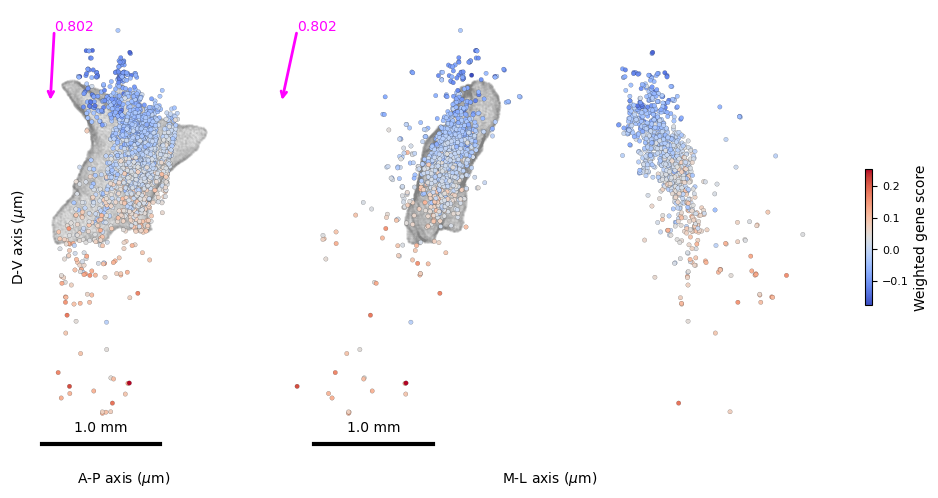

In [5]:
fig, (ax1, ax2) = plt.subplots(
    1, 2,figsize=(10, 5),
    gridspec_kw={'width_ratios': [1, 4]}
)

# Sagittal view (A-P vs D-V)
# ax1.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, color='lime', alpha=0.4)
ax1.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
# ax1.scatter(allspatial[:, 0], allspatial[:, 1], c=X_c[:, k], s=s, edgecolor='k', linewidth=0.1, cmap='Greys')
plotting.scatter_with_jitter(ax1, allspatial_j, X_c[:, k], direction='s', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
ax1.set_aspect('equal')

# Add vector arrow
start_point_all = np.min(allspatial, 0)
start_point = (start_point_all[0], start_point_all[1])
end_point = (start_point_all[0] + vector_scaled[0], start_point_all[1] + vector_scaled[1])
ax1.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax1.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')
ax1.invert_yaxis()
ax1.set_ylabel("D-V axis ($\mu$m)")
ax1.set_xlabel("A-P axis ($\mu$m)")
xt = ax1.get_xticks(); yt = ax1.get_yticks()
ax1.set_xticks(xt); ax1.set_yticks(yt)
ax1.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax1.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax1, length_px=40, linewidth=3, px_to_mm=25/1000)
ax1.set_xticks([])
ax1.set_yticks([])
for spine in ax1.spines.values():
    spine.set_visible(False)
    
# Coronal view (M-L vs D-V)
# ax2.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, color='lime', alpha=0.4)
ax2.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
# ax2.scatter(vertices[:, 0], vertices[:, 1], c='gray', s=1, alpha=0.05, label='LC Core Mesh')
# sca = ax2.scatter(allspatial[:, 2], allspatial[:, 1], c=X_c[:, k], s=s, edgecolor='k', linewidth=0.1, cmap='coolwarm')
sca=plotting.scatter_with_jitter(ax2, allspatial_j, X_c[:, k], direction='c', s=s, lw=0.1,scl_jitter=0.05, ascending=False, cmap ='coolwarm')
cbar = plt.colorbar(sca, ax=ax2, label='Weighted gene score', shrink=0.3)
ax2.set_aspect('equal')



# Add vector arrow
start_point = (start_point_all[2], start_point_all[1])
end_point = (start_point_all[2] + vector_scaled[2], start_point_all[1] + vector_scaled[1])
ax2.annotate('',xy=end_point,xytext=start_point,arrowprops=dict(arrowstyle="->", color="magenta", lw=2))
ax2.text(start_point[0], start_point[1], np.around(canonical_correlations[k], 3).astype(str), color='magenta')

ax2.invert_yaxis()
ax2.set_xlabel("M-L axis ($\mu$m)")
xt = ax2.get_xticks(); yt = ax2.get_yticks()
ax2.set_xticks(xt); ax2.set_yticks(yt)
ax2.set_xticklabels(plotting.format_ticklabels(xt, scale=25))
ax2.set_yticklabels(plotting.format_ticklabels(yt, scale=25))
plotting.draw_scale_bar(ax2, length_px=40, linewidth=3, px_to_mm=25*1e-3)
ax2.set_xticks([])
ax2.set_yticks([])
for spine in ax2.spines.values():
    spine.set_visible(False)
fig.tight_layout()
save_figure("cca")
plt.show()

# which gene have weights

In [6]:
def analyze_gene_correlations_with_cca(adata_mer, cca, X_c, component_idx=1):
    """Find genes correlated with CCA components"""
    print(f"Analyzing gene correlations with CCA component {component_idx}...")
    
    # Get CCA component and gene weights
    w = cca.x_weights_[:, component_idx]
    genes = np.array(adata_mer.var_names)
    score = X_c[:, component_idx]
    
    # Convert sparse matrix if needed
    X = adata_mer.X
    if hasattr(X, 'toarray'):
        X = X.toarray()
    
    # Calculate Spearman correlations
    corrs = []
    for j in range(X.shape[1]):
        rho, _ = spearmanr(X[:, j], score)
        corrs.append(rho)
    
    # Create results DataFrame
    df_results = pd.DataFrame({
        "gene": genes,
        "gene_weight": w,
        "spearman_corr": corrs,
        "abs_corr": np.abs(corrs)
    }).sort_values("abs_corr", ascending=False)
    
    print(f"\nTop 10 genes by correlation with CCA component {component_idx+1}:")
    print(df_results.head(10))
    
    return df_results

# Analyze gene correlations
df_gene_corr = analyze_gene_correlations_with_cca(adata_mer, cca, X_c, component_idx=1)

Analyzing gene correlations with CCA component 1...

Top 10 genes by correlation with CCA component 2:
        gene  gene_weight  spearman_corr  abs_corr
269    Tacr3    -0.152598       0.629108  0.629108
197     Pdyn    -0.007051      -0.615342  0.615342
183    Oprm1     0.025397      -0.553200  0.553200
275  Tmem178    -0.083476       0.521491  0.521491
281     Trhr     0.004796      -0.507977  0.507977
31     Calcr     0.081865      -0.472626  0.472626
194   Pde11a    -0.012507      -0.464908  0.464908
29     Calb2    -0.015482      -0.441356  0.441356
86      Esr1    -0.036142       0.433330  0.433330
203     Pon2     0.094224      -0.427731  0.427731


Saving figure to: /root/capsule/output/figures/merfish/cca_top_genes_table.svg
Saving figure to: /root/capsule/output/figures/merfish/cca_top_genes_table.png


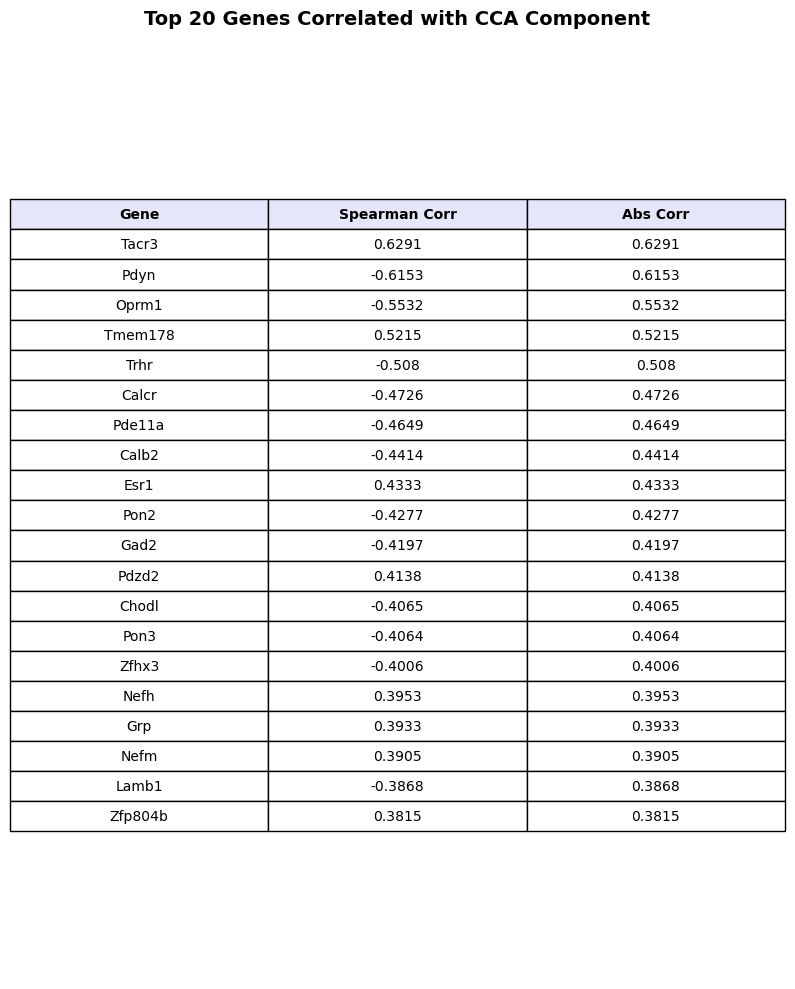

In [7]:
def create_gene_correlation_table(df_results, top_n=20):
    """Create and save a table of top correlated genes"""
    df_top = df_results.head(top_n)[['gene', 'spearman_corr', 'abs_corr']].copy()
    fig, ax = plt.subplots(figsize=(8, 10))
    ax.axis("off")
    tbl = ax.table(
        cellText=df_top.round(4).values,
        colLabels=['Gene', 'Spearman Corr', 'Abs Corr'],
        loc="center",
        cellLoc='center'
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1.2, 1.5)
    
    for (row, col), cell in tbl.get_celld().items():
        if row == 0:
            cell.set_text_props(weight="bold")
            cell.set_facecolor('#E6E6FA')
    
    plt.title(f'Top {top_n} Genes Correlated with CCA Component', 
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    save_figure("cca_top_genes_table")
    plt.show()

# Create correlation table
create_gene_correlation_table(df_gene_corr)

# visualize these genes in space

In [8]:
def create_colormaps(base_cmap_name=CMAP_NAME):
    """Create colormap configurations for gene visualization."""
    from matplotlib.colors import LinearSegmentedColormap    
    cmap_sele = plt.get_cmap(base_cmap_name)
    low_col = cmap_sele(0.0)   # RGBA for the "bottom" color
    high_col = cmap_sele(1.0)  # RGBA for the "top" color
    low_cmap = LinearSegmentedColormap.from_list("low_cmap", ["white", low_col])
    high_cmap = LinearSegmentedColormap.from_list("high_cmap", ["white", high_col])
    return low_col, high_col, low_cmap, high_cmap

low_col, high_col, low_cmap, high_cmap = create_colormaps()

In [9]:
low_col

(0.5568627450980392, 0.00392156862745098, 0.3215686274509804, 1.0)

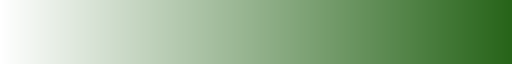

In [10]:
high_cmap

Visualizing high-corr genes...
Saving figure to: /root/capsule/output/figures/merfish/high_corr_genes_spatial.svg
Saving figure to: /root/capsule/output/figures/merfish/high_corr_genes_spatial.png


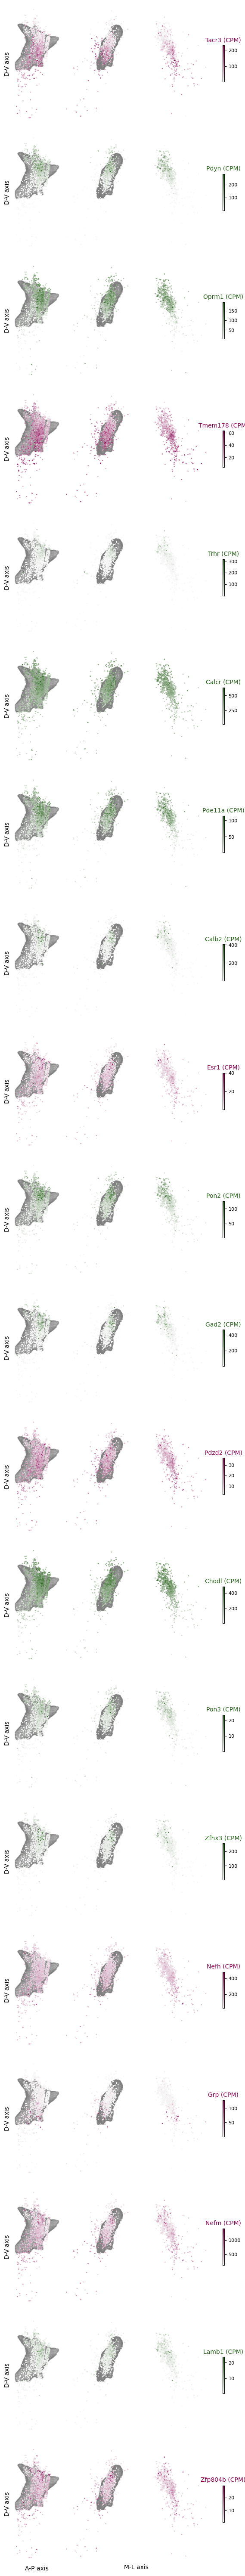

In [11]:
def plot_selected_genes(adata_mer, selected_genes, mesh, lowgenes, colors=None, s=3):
    if colors is None:
        colors = [high_col, low_col]
        cmapnames = [high_cmap, low_cmap, ]
    fig, axes = plt.subplots(len(selected_genes), 2, figsize=(6,3*len(selected_genes)),
        gridspec_kw={'width_ratios': [1, 4]})
    
    for k, gene in enumerate(selected_genes):
        if lowgenes[k]:
            cmap_use = low_cmap
            col_use = low_col
        else:
            cmap_use = high_cmap
            col_use = high_col
            
        # Sagittal view
        ax = axes[k, 0]
        plotorder = np.argsort(adata_mer[:, gene].X.flatten())
        ax.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     allspatial_j[plotorder], 
                                     cpm_scl*adata_mer[plotorder, gene].X.toarray().flatten(), 
                                     direction='s', s=s, lw=0.01,scl_jitter=0.05, ascending=True, cmap =cmap_use)
        ax.invert_yaxis()
        ax.set_ylabel("D-V axis")
        ax.set_xlabel("A-P axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Coronal view
        ax = axes[k, 1]
        ax.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     allspatial_j[plotorder], 
                                     cpm_scl*adata_mer[plotorder, gene].X.toarray().flatten(), 
                                     direction='c', s=s, lw=0.01,scl_jitter=0.05, ascending=True, cmap =cmap_use)
        cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.set_xlabel(f"{gene} (CPM)", ha='center', va='bottom', color = col_use)
        ax.set_xlabel("M-L axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.tight_layout()
    return fig

G = 20
print("Visualizing high-corr genes...")
highcorgenes = df_gene_corr[:G].gene.values.tolist()
lowgenes = df_gene_corr[:G]['spearman_corr'].values>0 # positive correlation should be 'low' which should be magenta, i think? 
fig = plot_selected_genes(adata_mer, highcorgenes, mesh, lowgenes)
save_figure("high_corr_genes_spatial")
plt.show()

# Visualize canonical variables on UMAP


Visualizing canonical variables on UMAP...
Saving figure to: /root/capsule/output/figures/merfish/merfish_umap.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_umap.png


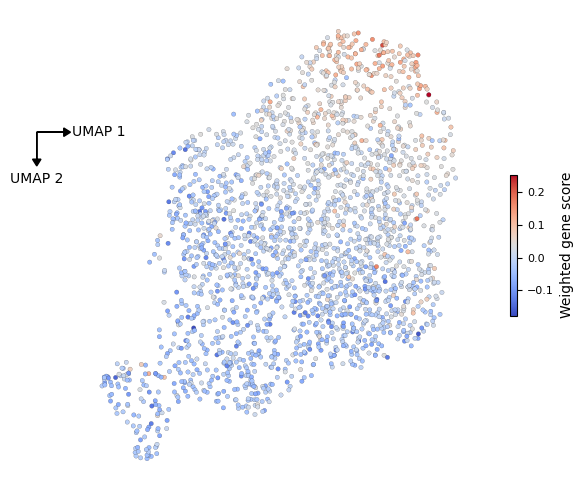

In [12]:
# Visualize canonical variables on UMAP embedding
print("Visualizing canonical variables on UMAP...")
s = 10
fs = 10
plt.figure(figsize=(7, 5))
ax = plt.gca()

sca = ax.scatter(adata_mer.obsm['X_umap'][:, 0], adata_mer.obsm['X_umap'][:, 1], 
                c=X_c[:, k], cmap='coolwarm', s=s, edgecolor='k', linewidth=0.1)
ax.set_aspect('equal')    
cbar = plt.colorbar(sca, ax=ax, label='Weighted gene score', shrink=0.3)

# Remove borders and ticks for clean appearance
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
ax.invert_yaxis()

# Add UMAP axis labels
y0, x0 = np.min(adata_mer.obsm['X_umap'], 0)
y0 *= 1.4
x0 *= 0.8
ax.arrow(x0, y0, 1, 0, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='k')
ax.arrow(x0, y0, 0, 1, head_width=0.25, head_length=0.2,
         length_includes_head=True, linewidth=1, color='black')

ax.text(x0+1.05, y0, 'UMAP 1', va='center', ha='left', fontsize=fs)
ax.text(x0, y0+1.6, 'UMAP 2', va='bottom', ha='center', fontsize=fs)
plt.tight_layout()
save_figure("merfish_umap")
plt.show()

# Find Genes Correlated with CCA Direction


In [13]:
# Find genes correlated with the CCA direction
print("Finding genes correlated with CCA direction...")
direction_of_interest = -cca.y_weights_[:, 1]
direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
projected = adata_mer.obsm['spatial'] @ direction_norm

# Convert sparse matrix to numpy array if needed
if hasattr(adata_mer.X, 'toarray'):
    X = adata_mer.X.toarray()
else:
    X = np.array(adata_mer.X)

gene_names = adata_mer.var_names
results = []
for i, gene in enumerate(gene_names):
    expr = X[:, i]
    corr, pval = spearmanr(expr, projected)
    results.append((gene, corr, pval))

df_results = pd.DataFrame(results, columns=['gene', 'spearman_corr', 'p_value'])
df_results_sorted = df_results.sort_values(by='spearman_corr', key=lambda s: s.abs(), ascending=False)

print("Top 10 correlated genes:")
print(df_results_sorted.head(10))

Finding genes correlated with CCA direction...
Top 10 correlated genes:
        gene  spearman_corr        p_value
269    Tacr3      -0.517972  7.749654e-155
197     Pdyn       0.489750  3.498880e-136
275  Tmem178      -0.477582  1.153106e-128
183    Oprm1       0.449680  1.567966e-112
281     Trhr       0.412203   4.217461e-93
194   Pde11a       0.400310   1.960348e-87
86      Esr1      -0.377097   5.083481e-77
161     Nefh      -0.369869   6.027955e-74
99      Gad2       0.359137   1.589703e-69
119      Grp      -0.353472   2.932930e-67


# Gene Imputation and Visualization

In [14]:
def load_and_impute_data(adata_mer, snrna_data_path, k=200, n_hvg=None):
    """Load scRNA-seq data and impute MERFISH gene expression."""
    print("Loading scRNA-seq data for imputation...")
    adata_foo = sc.read_h5ad(snrna_data_path)
    adata_sc = sc.AnnData(adata_foo.layers['BN'])
    adata_sc.obs = adata_foo.obs.copy()
    adata_sc.obsm = adata_foo.obsm.copy()
    adata_sc.var = adata_foo.var.copy()

    # Subset MERFISH data to match genes in scRNA-seq
    var_names = adata_mer.var_names.intersection(adata_sc.var_names)
    adata_mer_foo = adata_mer[:, var_names]
    print(f"Number of shared genes for imputation: {len(var_names)}")

    # Impute MERFISH data
    print("Imputing gene expression data...")
    adata_mer_imputed = imputations.impute_mer_data(adata_sc, adata_mer_foo, k=k, n_hvg=n_hvg, softmax_dst = True)
    adata_mer_imputed.obsm['spatial'] = adata_mer.obsm['spatial'].copy()
    
    return adata_mer_imputed, adata_sc

# Load and impute data
snrna_data_path = os.path.join(SNRNA_DATA_DIR, "snRNAseq_LCNE_BN_d4_merbar_1-5k.h5ad")
adata_mer_imputed, adata_sc = load_and_impute_data(adata_mer, snrna_data_path)

Loading scRNA-seq data for imputation...
Number of shared genes for imputation: 303
Imputing gene expression data...
union!  1758


# Visualize Selected Genes in Spatial Coordinates

Visualizing selected genes...
Saving figure to: /root/capsule/output/figures/merfish/two_genes_examples.svg
Saving figure to: /root/capsule/output/figures/merfish/two_genes_examples.png


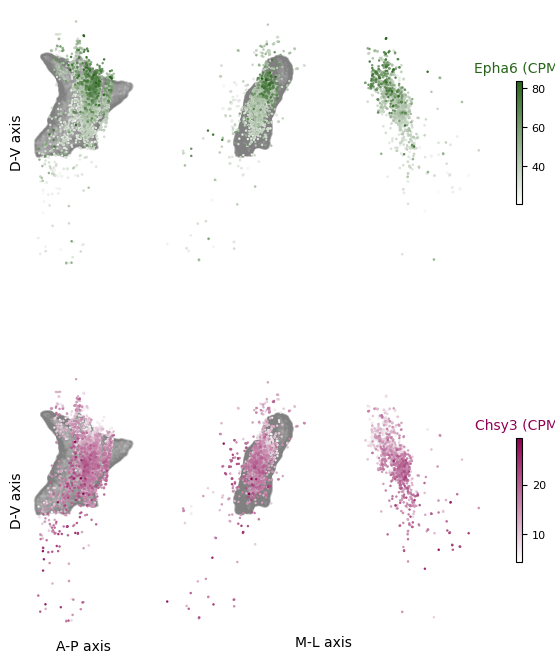

In [15]:
def plot_selected_genes(adata_imputed, selected_genes, mesh, colors=None, s=3):
    if colors is None:
        colors = [high_col, low_col]
        cmapnames = [high_cmap, low_cmap, ]
    
    fig, axes = plt.subplots(len(selected_genes), 2, figsize=(6, 8),
        gridspec_kw={'width_ratios': [1, 4]})
    
    for k, gene in enumerate(selected_genes):
        # Sagittal view
        ax = axes[k, 0]
        plotorder = np.argsort(adata_imputed[:, gene].X.flatten())
        # ax.triplot(mesh.vertices.T[0], mesh.vertices.T[1], mesh.faces, alpha=0.4, color='lime')
        ax.scatter(mesh.vertices.T[0], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     allspatial_j[plotorder], 
                                     cpm_scl*adata_imputed[plotorder, gene].X.toarray(), 
                                     direction='s', s=s, lw=0.01,scl_jitter=0.05, ascending=False, cmap =cmapnames[k])
        # sca = ax.scatter(
        #     adata_imputed.obsm['spatial'][plotorder, 0],
        #     adata_imputed.obsm['spatial'][plotorder, 1],
        #     cmap=cmapnames[k], s=s, edgecolor='k', linewidth=0.01,
        #     c=cpm_scl*adata_imputed[plotorder, gene].X.toarray()
        # )
        ax.invert_yaxis()
        ax.set_ylabel("D-V axis")
        ax.set_xlabel("A-P axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_aspect('equal')
        for spine in ax.spines.values():
            spine.set_visible(False)
        
        # Coronal view
        ax = axes[k, 1]
        # ax.triplot(mesh.vertices.T[2], mesh.vertices.T[1], mesh.faces, alpha=0.4, color='lime')
        ax.scatter(mesh.vertices.T[2], mesh.vertices.T[1], c='gray', s=1, alpha=0.05)
        sca = plotting.scatter_with_jitter(ax, 
                                     allspatial_j[plotorder], 
                                     cpm_scl*adata_imputed[plotorder, gene].X.toarray(), 
                                     direction='c', s=s, lw=0.01,scl_jitter=0.05, ascending=False, cmap =cmapnames[k])
        # sca = ax.scatter(
        #     adata_imputed.obsm['spatial'][plotorder, 2],
        #     adata_imputed.obsm['spatial'][plotorder, 1],
        #     cmap=cmapnames[k], s=s, edgecolor='k', linewidth=0.05,
        #     c=cpm_scl*adata_imputed[plotorder, gene].X.toarray()
        # )
        cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
        cbar.ax.xaxis.set_label_position('top')
        cbar.ax.set_xlabel(f"{gene} (CPM)", ha='center', va='bottom', color=colors[k])
        ax.set_xlabel("M-L axis") if k == len(selected_genes)-1 else ax.set_xlabel('')
        ax.invert_yaxis()
        ax.set_aspect('equal')
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)
    fig.tight_layout()
    return fig

print("Visualizing selected genes...")
selected_genes = ['Epha6', 'Chsy3']
fig = plot_selected_genes(adata_mer_imputed, selected_genes, mesh)
save_figure("two_genes_examples")
plt.show()

# Generate Heatmap of Gene Expression


Creating gene expression heatmap...
Saving figure to: /root/capsule/output/figures/merfish/merfish_heatmap.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_heatmap.png


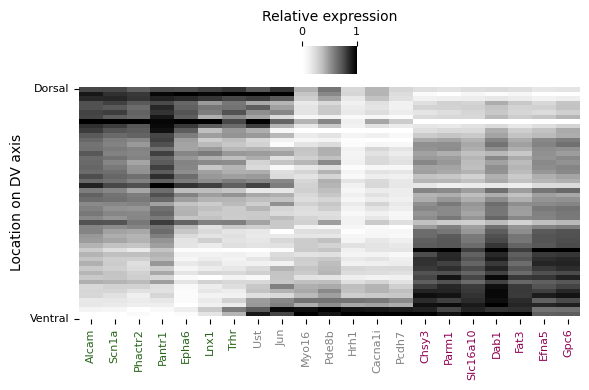

In [16]:
def create_gene_expression_heatmap(adata_imputed, cca, output_dir, gene_list_file='allyourgenes.pkl'):
    """Create a heatmap of gene expression ordered by CCA direction."""
    import pickle
    k = 1
    direction_of_interest = (cca.y_weights_[:, k]) 
    direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
    projected = adata_mer.obsm['spatial'] @ direction_norm

    # Load gene list
    output_file = os.path.join(output_dir, gene_list_file)
    allyourgenes = pickle.load(file = open(output_file,'rb'))

    # Check gene availability
    available_genes = [gene for gene in allyourgenes if gene in adata_imputed.var_names]

    # Sort cells by position along the CCA direction
    t_order = np.argsort(projected)
    inputheatmap = adata_imputed[:, available_genes].X.toarray()[t_order].T
    ordered_data, row_order = heatmap.get_final_heatmap(inputheatmap, gene_reorder = False)

    # Define color grouping for genes (for visualization)
    T = int(len(row_order)/3)
    tick_colors = []
    for orig_idx in row_order:
        if orig_idx < T:
            tick_colors.append(high_col)
        elif orig_idx >= 2*T:
            tick_colors.append(low_col)
        else:
            tick_colors.append('gray')

    # Create heatmap
    print("Creating gene expression heatmap...")
    plt.figure(figsize=(6, 4))
    sns.heatmap(
        ordered_data.T,
        cmap='Greys',
        cbar_kws={
            'location': 'top',
            'label': 'Relative expression',
            'shrink': 0.3,
            'aspect': 2,
            'fraction': 0.1
        }
    )

    # Set xtick labels and colors
    xtick_labels = [available_genes[l] for l in row_order]
    xticks = plt.gca().get_xticks()
    plt.xticks(ticks=xticks, labels=xtick_labels, rotation=90)
    for tick, color in zip(plt.gca().get_xticklabels(), tick_colors):
        tick.set_color(color)

    plt.ylabel('Location on DV axis')
    q = 2  # How many labels to show on y-axis
    plt.yticks(
        np.arange(q)*(ordered_data.shape[1]//(q-1))+0.5, 
        ['Dorsal', 'Ventral'], 
        rotation=0
    )
    plt.grid(False)
    plt.tight_layout()
    return plt.gcf()

# Create heatmap
fig = create_gene_expression_heatmap(adata_mer_imputed, cca, TMP_OUT_DIR)
save_figure("merfish_heatmap")
plt.show()


# Impute Pseudoclusters from scRNAseq to MERFISH

In [17]:
def impute_pseudoclusters(adata_mer, adata_sc, output_dir, k=100):
    """Impute pseudoclusters from scRNA-seq to MERFISH data."""
    print("Imputing pseudoclusters...")
    
    # Find common genes between datasets
    common_genes_mer = np.intersect1d(adata_mer.var_names, adata_sc.var_names)
    adata_mer_subset = adata_mer[:, common_genes_mer]
    
    # Perform pseudocluster imputation
    imp_mer, conf_mer = imputations.impute_pseudocluster(
        adata_mer_subset, adata_sc, pc_dir=output_dir, k=k,  softmax_dst = False)
    
    # Add results to AnnData object
    adata_mer.obs['imputed pseudocluster'] = imp_mer
    
    return imp_mer, conf_mer

# Impute pseudoclusters
imp_mer, conf_mer = impute_pseudoclusters(adata_mer, adata_sc, TMP_OUT_DIR)

Imputing pseudoclusters...
using 303 genes to run the imputations!


In [18]:
S_mer = processing.get_hemi(allspatial_j, MESH_DIR)

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc.png


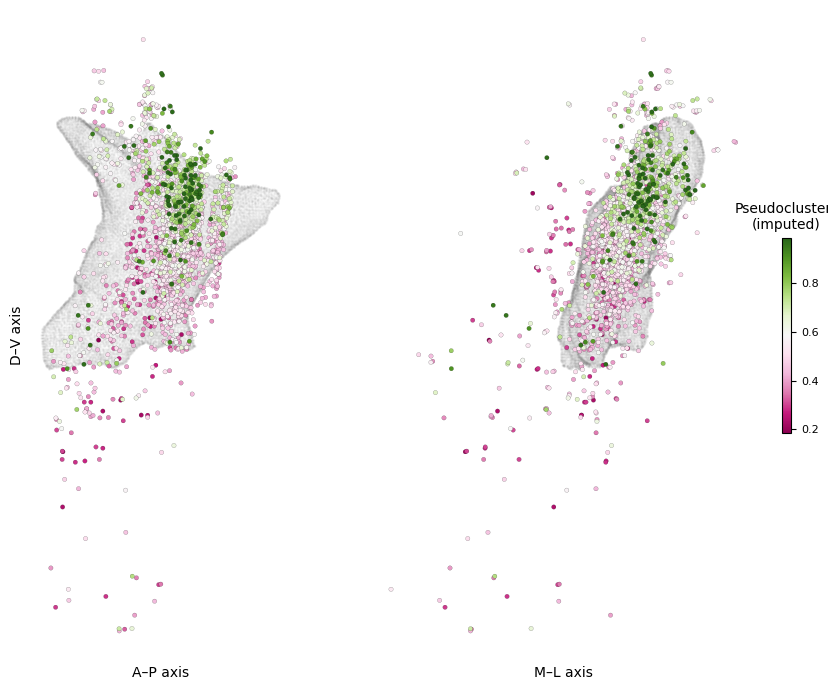

In [19]:
def plot_pseudoclusters(adata_mer, S_mer, mesh, s=10, scl_jitter=0.05, save_name="merfish_pc"):
    
    """Plot imputed pseudoclusters in spatial coordinates."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7), gridspec_kw={'width_ratios': [1, 2]})
    
    # ——— Left: Sagittal view (direction='s') ———
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax1, S_mer, adata_mer.obs['imputed pseudocluster'], 
                                 direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='PiYG')

    ax1.set_aspect('equal')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    # ——— Right: Coronal view (direction='c') ———
    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, S_mer, adata_mer.obs['imputed pseudocluster'], 
                                 direction='c', s=s, lw=0.1, scl_jitter=scl_jitter, ascending=True, cmap='PiYG')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Pseudoclusters\n(imputed)", ha='center', va='bottom')
    ax2.set_aspect('equal')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    fig.tight_layout()
    save_figure(save_name)
    return fig

# Plot pseudoclusters
fig = plot_pseudoclusters(adata_mer, S_mer,mesh)
plt.show()

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_CI.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_CI.png


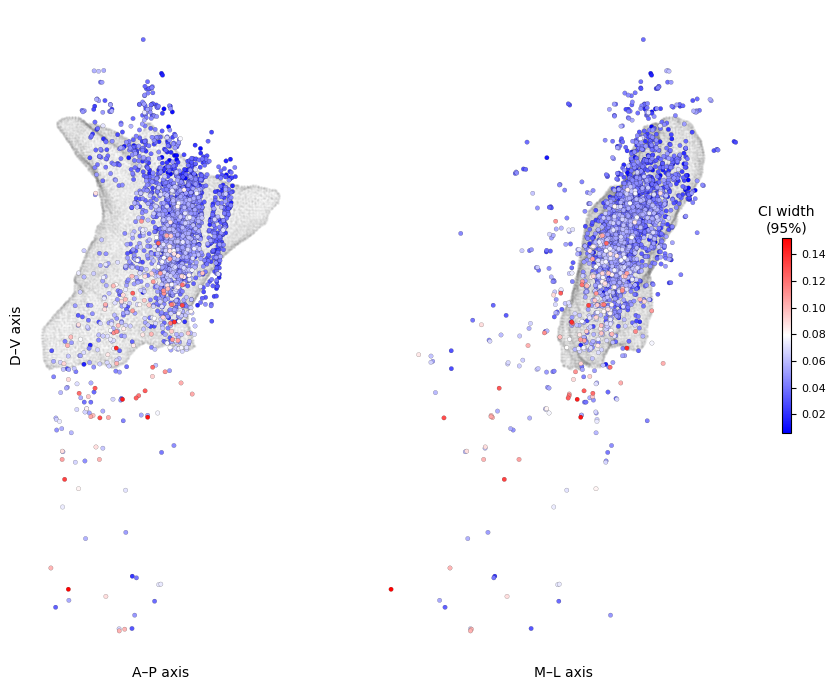

In [20]:
def plot_confidence_metrics(adata_mer, S_mer,conf_mer, mesh, s=10, scl_jitter=0.05):
    """Plot confidence interval width and confidence power for pseudocluster imputation."""
    
    # Calculate and store confidence interval width
    ci_width = conf_mer['ci_upper'] - conf_mer['ci_lower']
    adata_mer.obs['pc_ci_width'] = ci_width

    # Plot CI width
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7), gridspec_kw={'width_ratios': [1, 2]})
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, S_mer, ci_width, direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='bwr')
    ax1.set_aspect('equal')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, S_mer, ci_width, direction='c', s=s, lw=0.1, scl_jitter=scl_jitter, ascending=True, cmap='bwr')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("CI width\n(95%)", ha='center')
    ax2.set_aspect('equal')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    fig.tight_layout()
    save_figure("merfish_pc_CI")
    plt.show()
    
    return fig

# Plot confidence metrics
fig = plot_confidence_metrics(adata_mer, S_mer,conf_mer, mesh)

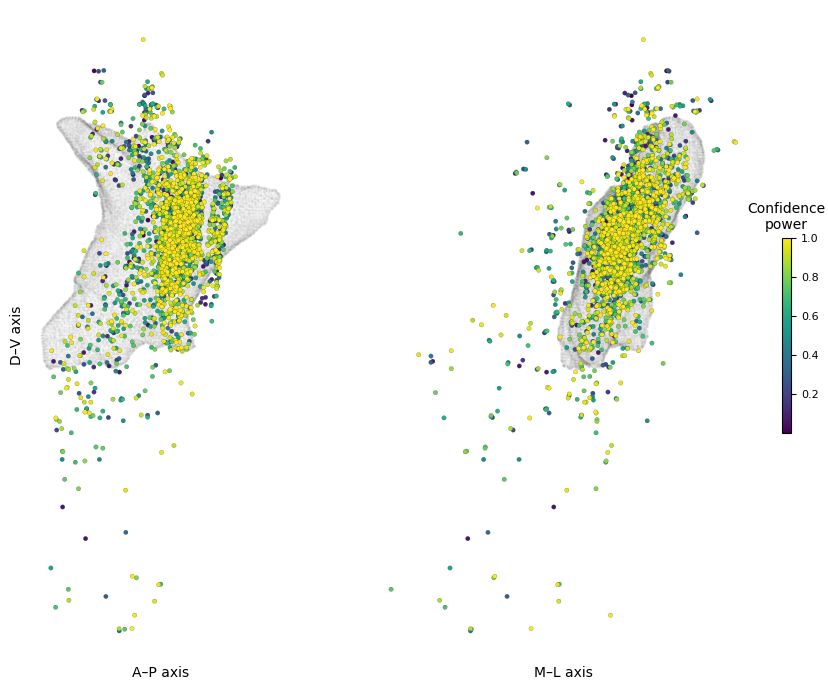

In [21]:
def plot_confidence_power(conf_mer, S_mer,mesh, s=10, scl_jitter=0.05):
    """Plot confidence power for pseudocluster imputation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7), gridspec_kw={'width_ratios': [1, 2]})
    
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, S_mer, conf_mer['conf_power'], direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True)
    ax1.set_aspect('equal')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, S_mer, conf_mer['conf_power'], direction='c', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True)
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Confidence\npower", ha='center', va='bottom')
    ax2.set_aspect('equal')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    fig.tight_layout()
    # save_figure("merfish_confidence")
    return fig

# Plot confidence power
fig = plot_confidence_power(conf_mer, S_mer,mesh)
plt.show()

Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_std.svg
Saving figure to: /root/capsule/output/figures/merfish/merfish_pc_std.png


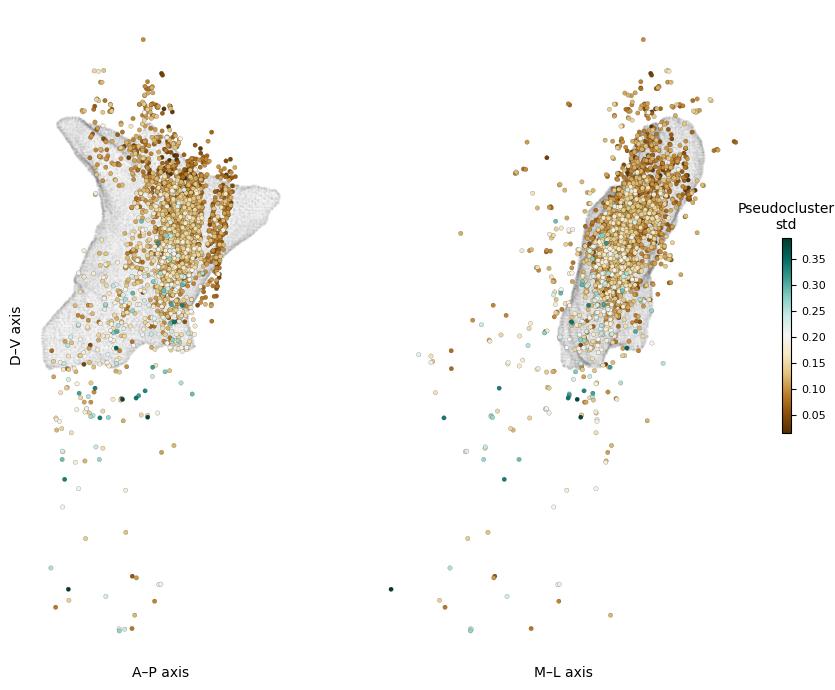

Notebook cleanup completed! All functions have been organized and redundancy removed.


In [22]:
def plot_pseudocluster_std(conf_mer,S_mer,mesh, s=10, scl_jitter=0.05):
    """Plot pseudocluster standard deviation."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 7), gridspec_kw={'width_ratios': [1, 2]})
    
    plotting.plot_mesh(ax1, mesh, direction='s', meshcol='lime')
    plotting.scatter_with_jitter(ax1, S_mer, conf_mer['pc_std'], direction='s', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='BrBG')
    ax1.set_aspect('equal')
    ax1.set_ylabel("D–V axis")
    ax1.set_xlabel("A–P axis")
    ax1.set_xticks([]); ax1.set_yticks([])
    for spine in ax1.spines.values():
        spine.set_visible(False)

    plotting.plot_mesh(ax2, mesh, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax2, S_mer, conf_mer['pc_std'], direction='c', lw=0.1, s=s, scl_jitter=scl_jitter, ascending=True, cmap='BrBG')
    cbar = plt.colorbar(sca, ax=ax2, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("Pseudocluster\nstd", ha='center', va='bottom')
    ax2.set_aspect('equal')
    ax2.set_xlabel("M–L axis")
    ax2.set_xticks([]); ax2.set_yticks([])
    for spine in ax2.spines.values():
        spine.set_visible(False)
        
    fig.tight_layout()
    save_figure("merfish_pc_std")
    return fig

# Plot pseudocluster standard deviation
fig = plot_pseudocluster_std(conf_mer, S_mer,mesh)
plt.show()

print("Notebook cleanup completed! All functions have been organized and redundancy removed.")

# scatter plot (btw DV axis and pseudocluster score)

Text(0, 0.5, 'DV axis coords')

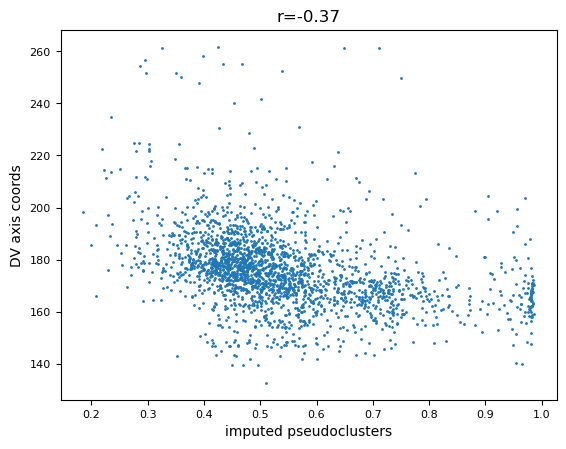

In [23]:
corrcoeff_dv_pc = np.corrcoef( adata_mer.obs['imputed pseudocluster'],S_mer[:,1])[0,1]

plt.scatter( adata_mer.obs['imputed pseudocluster'] ,S_mer[:,1], s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('DV axis coords')

Text(0, 0.5, 'vector projection')

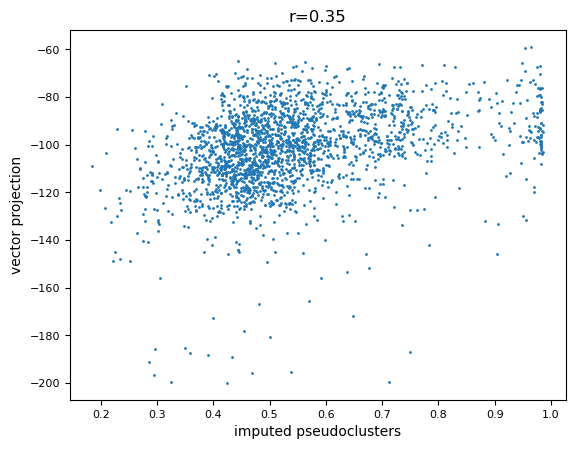

In [24]:
# direction_of_interest = -cca.y_weights_[:, 1]
# direction_norm = direction_of_interest / np.linalg.norm(direction_of_interest)
# projected = adata_mer.obsm['spatial'] @ direction_norm


corrcoeff_dv_pc = np.corrcoef(adata_mer.obs['imputed pseudocluster'],projected)[0,1]

plt.scatter(adata_mer.obs['imputed pseudocluster'], projected,s=1)
plt.title(f'r={np.around(corrcoeff_dv_pc,2)}')
plt.xlabel('imputed pseudoclusters')
plt.ylabel('vector projection')

# Visualize Retroseq DE Genes


/tmp/ipykernel_6288/1436513423.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_6288/1436513423.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_6288/1436513423.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = 

Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_s.svg
Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_s.png


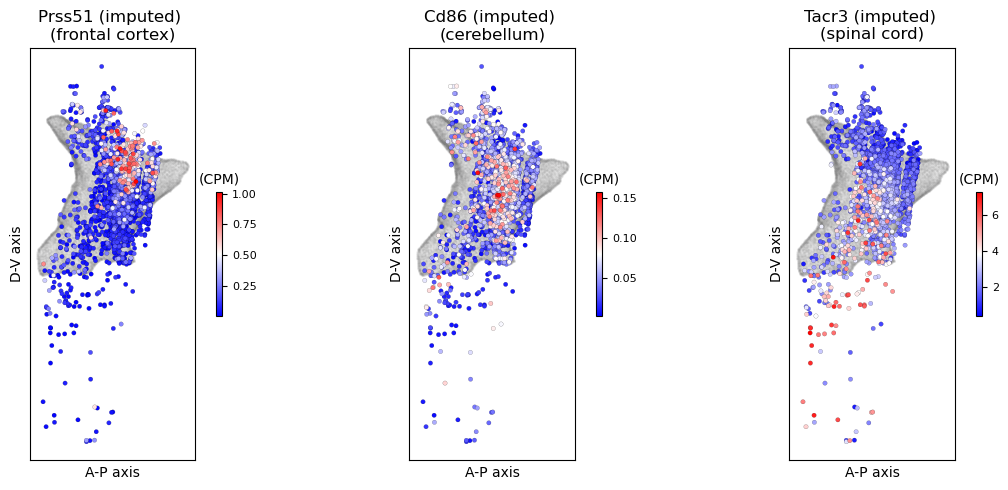

/tmp/ipykernel_6288/1436513423.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_6288/1436513423.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
/tmp/ipykernel_6288/1436513423.py:71: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sca = 

Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_c.svg
Saving figure to: /root/capsule/output/figures/merfish/retro_DE_distrb_c.png


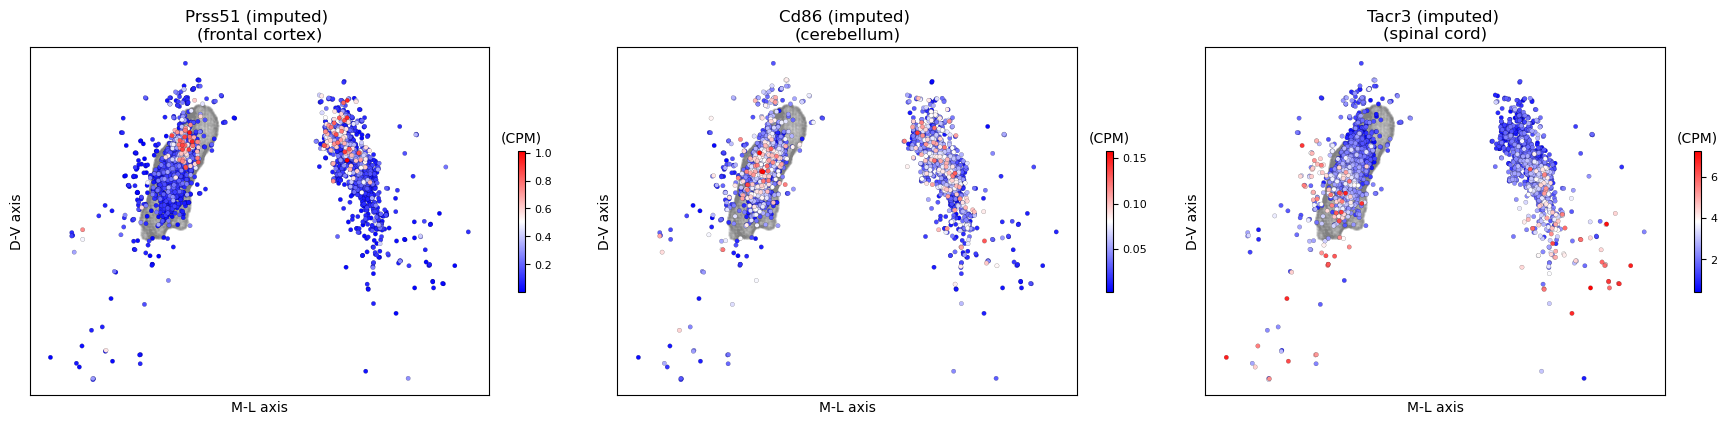

In [25]:
scl_jitter = 0.05
retro_DE_genes = np.array([['Prss51',
  'Mbl2',
  'Ptgs2',
  'Tlr5',
  'Scnn1a',
  'Adcy8',
  'Tph2',
  'Csta2',
  'Vrk2',
  'Cyct'], # frontal cortex
                         [ 'Cd86',
  'Slc25a48',
  'Slpi',
  'Efemp1',
  'Ms4a4c',
  'Chrna2',
  'Pdgfrb',
  'Mcm2',
  'Rasef',
  'Tmem270'],  # cerebellum
                          ['Tacr3',
  'Tshr',
  'Syndig1',
  'Tshz2',
  'Glra3',
  'Chsy3',
  'Rspo2',
  'Esr1',
  'Rbfox3',
  'Pcdh7']]) # spinal cord

projectionsite_list = ['frontal cortex', 'cerebellum', 'spinal cord']
genes_i_like = retro_DE_genes[:,0]
adata_mer = imputations.replace_imputedvalues(adata_mer, adata_mer_imputed, genes_i_like)

coords = allspatial_j.copy()
# Sagittal view
s = 10
fig, axes = plt.subplots(1, 3, squeeze=False, figsize=(12, 5))
axes = axes.flatten()
for i, gene in enumerate(genes_i_like):
    ax = axes[i]    
    color_values = adata_mer.obs[f'imput_{gene}']*cpm_scl
    neworder = np.argsort(color_values)
    plotting.plot_mesh(ax, allmeshes, direction='s', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
                             direction='s', s=s, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
    cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel("(CPM)", ha='center', va='bottom')    
    ax.set_ylabel("D-V axis")
    ax.set_xlabel("A-P axis")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{gene} (imputed) \n({projectionsite_list[i]})')
    ax.grid(False)

fig.tight_layout()    
save_figure("retro_DE_distrb_s")
plt.show()

# Coronal view
fig, axes = plt.subplots(1, 3, squeeze=False, figsize=(18, 5))
axes = axes.flatten()
for i, gene in enumerate(genes_i_like):
    ax = axes[i]
    color_values = adata_mer.obs[f'imput_{gene}']*cpm_scl
    neworder = np.argsort(color_values)
    plotting.plot_mesh(ax, allmeshes, direction='c', meshcol='lime')
    sca = plotting.scatter_with_jitter(ax, coords[neworder], color_values[neworder], lw=0.1,
                             direction='c', s=s, scl_jitter=scl_jitter, ascending=True, cmap ='bwr')
    cbar = plt.colorbar(sca, ax=ax, shrink=0.3)
    cbar.ax.xaxis.set_label_position('top')
    cbar.ax.set_xlabel(f"(CPM)", ha='center', va='bottom')    
    ax.set_ylabel("D-V axis")
    ax.set_xlabel("M-L axis")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(f'{gene} (imputed) \n({projectionsite_list[i]})')
    ax.grid(False)

fig.tight_layout() 
save_figure("retro_DE_distrb_c")
plt.show()

# complete!

In [26]:
print("Analysis complete! All visualizations have been saved to:", fig_path)

Analysis complete! All visualizations have been saved to: /root/capsule/output/figures/merfish


In [27]:
fig_path


'/root/capsule/output/figures/merfish'